In [19]:
import pandas as pd
import numpy as np

import re
import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df=pd.read_csv('blogs.csv')

In [14]:
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [15]:
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [17]:
df['Labels'].value_counts()


Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64

In [20]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nalla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
def clean_text(text):
    text = text.lower()                     
    text = re.sub(r'[^a-z\s]', '', text)   
    tokens = text.split()                  
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)


In [23]:
df['cleaned_text'] = df['Data'].apply(clean_text)


In [24]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])
y = df['Labels']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [26]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
y_pred = nb_model.predict(X_test)


In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.85


In [29]:
print(classification_report(y_test, y_pred))


                          precision    recall  f1-score   support

             alt.atheism       0.84      0.80      0.82        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.84      0.80      0.82        20
comp.sys.ibm.pc.hardware       0.58      0.75      0.65        20
   comp.sys.mac.hardware       0.83      0.75      0.79        20
          comp.windows.x       0.84      0.80      0.82        20
            misc.forsale       0.86      0.90      0.88        20
               rec.autos       0.86      0.95      0.90        20
         rec.motorcycles       0.94      0.85      0.89        20
      rec.sport.baseball       1.00      0.95      0.97        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.87      1.00      0.93        20
         sci.electronics       0.84      0.80      0.82        20
                 sci.med       0.89      0.80      0.84        20
         

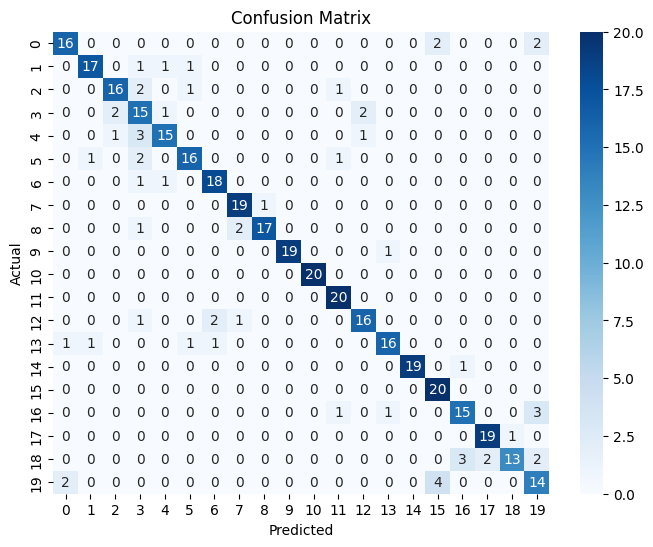

In [30]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [31]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nalla\AppData\Roaming\nltk_data...


In [32]:
def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


In [33]:
df['Sentiment'] = df['Data'].apply(get_sentiment)


In [34]:
sentiment_summary = pd.crosstab(df['Labels'], df['Sentiment'])
sentiment_summary


Sentiment,Negative,Neutral,Positive
Labels,,,
alt.atheism,42,1,57
comp.graphics,13,4,83
comp.os.ms-windows.misc,24,2,74
comp.sys.ibm.pc.hardware,21,0,79
comp.sys.mac.hardware,24,3,73
comp.windows.x,20,2,78
misc.forsale,7,8,85
rec.autos,27,1,72
rec.motorcycles,30,2,68


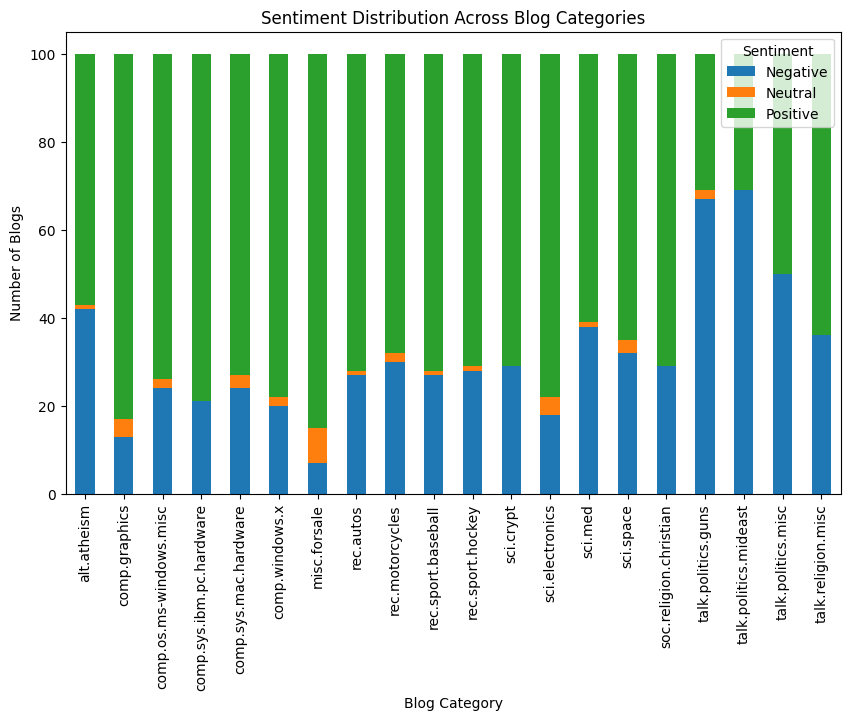

In [35]:
sentiment_summary.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment Distribution Across Blog Categories")
plt.xlabel("Blog Category")
plt.ylabel("Number of Blogs")
plt.show()


### Analysis

#### 1. Classification Report Analysis

- The model achieved an overall accuracy of 85%, showing good performance for multi-class text classification.

- Macro and weighted F1-scores (0.85) indicate balanced performance across categories.

- Categories like rec.sport.hockey, rec.sport.baseball, sci.space performed extremely well due to clear and distinct vocabulary.

- Moderate performance is observed in computer-related categories, where overlapping terms exist.

- Lower F1-scores in talk.politics.misc and talk.religion.misc are due to mixed and ambiguous content.

#### 2. Confusion Matrix Analysis

- Most values lie along the diagonal, indicating correct predictions.

- Misclassifications mainly occur between similar topic categories (e.g., computer hardware vs software).

- Sports and science categories show very minimal confusion.

- Errors are caused by semantic similarity, not model inefficiency.

#### 3. Sentiment Distribution Analysis

- Positive sentiment dominates across most blog categories.

- Sports and science blogs show high positivity, reflecting enthusiasm and informative tone.

- Political categories contain higher negative sentiment due to debates and criticism.

- Neutral sentiment is minimal, indicating opinion-oriented writing.